# Classification

**Goal:** Train and compare four classifiers (KNN, SVM, Logistic Regression, Random Forest)  
on the cluster labels from Step 4 then save the best pipeline.

**Workflow:**
1. Load labeled data  
2. Train / test split  
3. Balance classes (RandomOverSampler)  
4. Build pipelines (StandardScaler + classifier)  
5. Tune with GridSearchCV  
6. Evaluate (confusion matrix, F1, precision, recall)  
7. Compare all models  
8. Save the best pipeline  


## [0] Imports

In [17]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay

from diasense.classification import (
    load_labeled_data, split_data, balance_classes,
    build_model_pipeline, tune_model, evaluate_model,
    train_all_models, get_best_model, save_pipeline,
    load_pipeline, BASE_ESTIMATORS, PARAM_GRIDS,
)
from diasense.config import CLINICAL_FEATURES, MODELS_DIR
print('All imports OK')


All imports OK


## [1] Load the Labeled Dataset

clinical features + `Cluster` (target) + `risk_category`.


In [18]:
df = load_labeled_data()
print('Shape:', df.shape)
print()
print('Target distribution:')
print(df['Cluster'].value_counts())
df.head()


Loaded 768 rows, 10 columns
Shape: (768, 10)

Target distribution:
Cluster
1    499
0    269
Name: count, dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Cluster,risk_category
0,6,148,72,35,0,33.6,0.627,50,0,High Risk
1,1,85,66,29,0,26.6,0.351,31,1,Low Risk
2,8,183,64,0,0,23.3,0.672,32,0,High Risk
3,1,89,66,23,94,28.1,0.167,21,1,Low Risk
4,0,137,40,35,168,43.1,2.288,33,0,High Risk


## [2]Train / Test Split

- 80% train, 20% test
- `stratify=y` keeps class ratio equal in both sets
- `random_state=42` for reproducibility


In [19]:
X_train, X_test, y_train, y_test = split_data(df)


Train size : 614 samples
Test  size : 154 samples
Class distribution in train:
Cluster
1    399
0    215
Name: count, dtype: int64



## [3] Handle Class Imbalance

**RandomOverSampler** duplicates minority class rows in the training set only.  
The test set stays untouched so evaluation reflects reality.


Class distribution after oversampling:
Cluster
0    399
1    399
Name: count, dtype: int64


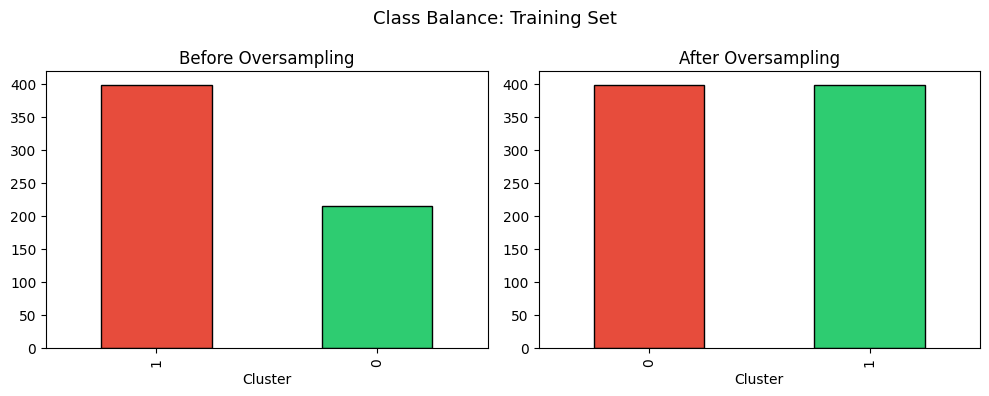

In [20]:
X_train_bal, y_train_bal = balance_classes(X_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
colors = ['#e74c3c', '#2ecc71']
y_train.value_counts().plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Before Oversampling'); axes[0].set_xlabel('Cluster')
y_train_bal.value_counts().plot(kind='bar', ax=axes[1], color=colors, edgecolor='black')
axes[1].set_title('After Oversampling'); axes[1].set_xlabel('Cluster')
plt.suptitle('Class Balance: Training Set', fontsize=13)
plt.tight_layout(); plt.show()


## [4] Pipeline: StandardScaler + Classifier

A Pipeline ensures the scaler is fitted only on the training fold during CV | no data leakage.


In [21]:
from sklearn.neighbors import KNeighborsClassifier
print(build_model_pipeline(KNeighborsClassifier()))


Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', KNeighborsClassifier())])


## [5] Hyperparameter Grids

GridSearchCV tests every combination with 5-fold CV, scored by `f1_weighted`.


In [22]:
for name, grid in PARAM_GRIDS.items():
    n = 1
    for v in grid.values(): n *= len(v)
    print(f'{name:25s}: {n} combinations')
    for p, vals in grid.items(): print(f'   {p}: {vals}')
    print()


KNN                      : 20 combinations
   classifier__n_neighbors: [3, 5, 7, 9, 11]
   classifier__weights: ['uniform', 'distance']
   classifier__metric: ['euclidean', 'manhattan']

SVM                      : 12 combinations
   classifier__C: [0.1, 1, 10]
   classifier__kernel: ['rbf', 'linear']
   classifier__gamma: ['scale', 'auto']

Logistic Regression      : 8 combinations
   classifier__C: [0.01, 0.1, 1, 10]
   classifier__solver: ['lbfgs', 'liblinear']
   classifier__max_iter: [500]

Random Forest            : 12 combinations
   classifier__n_estimators: [100, 200]
   classifier__max_depth: [None, 5, 10]
   classifier__min_samples_split: [2, 5]



## [6] Train and Tune All Models

Trains KNN, SVM, Logistic Regression, and Random Forest on the same balanced  
training data and evaluates on the same test set


In [23]:
results_df, fitted_models = train_all_models(
    X_train_bal, y_train_bal, X_test, y_test,
)



────────────────────────────────────────
  Training : KNN
────────────────────────────────────────
  Best params : {'classifier__metric': 'manhattan', 'classifier__n_neighbors': 11, 'classifier__weights': 'distance'}
  Best CV f1_weighted : 0.9562

  Results for: KNN
  Accuracy : 0.8506
  F1-Score : 0.8471

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.70      0.77        54
           1       0.85      0.93      0.89       100

    accuracy                           0.85       154
   macro avg       0.85      0.82      0.83       154
weighted avg       0.85      0.85      0.85       154

Confusion Matrix:
[[38 16]
 [ 7 93]]

────────────────────────────────────────
  Training : SVM
────────────────────────────────────────
  Best params : {'classifier__C': 10, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}
  Best CV f1_weighted : 0.9774

  Results for: SVM
  Accuracy : 0.9545
  F1-Score : 0.9544

Classification

## [7] Model Comparison

In [24]:
results_df.style.highlight_max(subset=['Accuracy','F1-Score'], color='lightgreen')


,Model,Accuracy,F1-Score
0,SVM,0.954500,0.954400
1,Logistic Regression,0.941600,0.941700
2,Random Forest,0.922100,0.921300
3,KNN,0.850600,0.847100


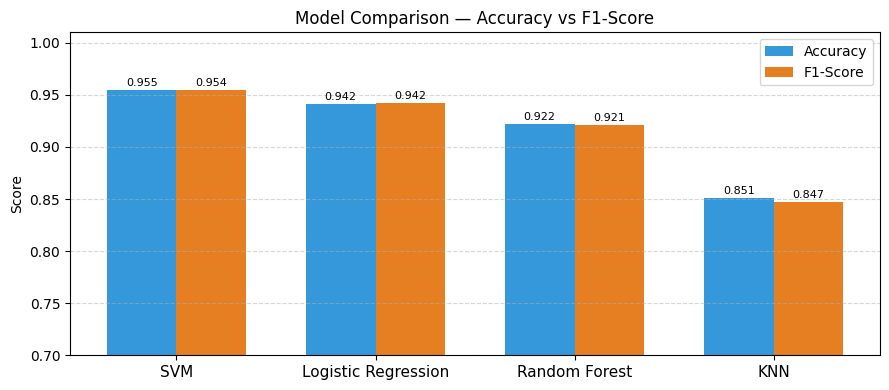

In [25]:
fig, ax = plt.subplots(figsize=(9, 4))
x = range(len(results_df)); w = 0.35
b1 = ax.bar([i-w/2 for i in x], results_df['Accuracy'], w, label='Accuracy', color='#3498db')
b2 = ax.bar([i+w/2 for i in x], results_df['F1-Score'], w, label='F1-Score', color='#e67e22')
ax.set_xticks(list(x)); ax.set_xticklabels(results_df['Model'], fontsize=11)
ax.set_ylim(0.7, 1.01); ax.set_ylabel('Score')
ax.set_title('Model Comparison — Accuracy vs F1-Score')
ax.legend(); ax.grid(axis='y', linestyle='--', alpha=0.5)
for b in list(b1)+list(b2):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.002,
            f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout(); plt.show()


## [8] Confusion Matrices

Rows = actual class | Columns = predicted class.


Figure saved.


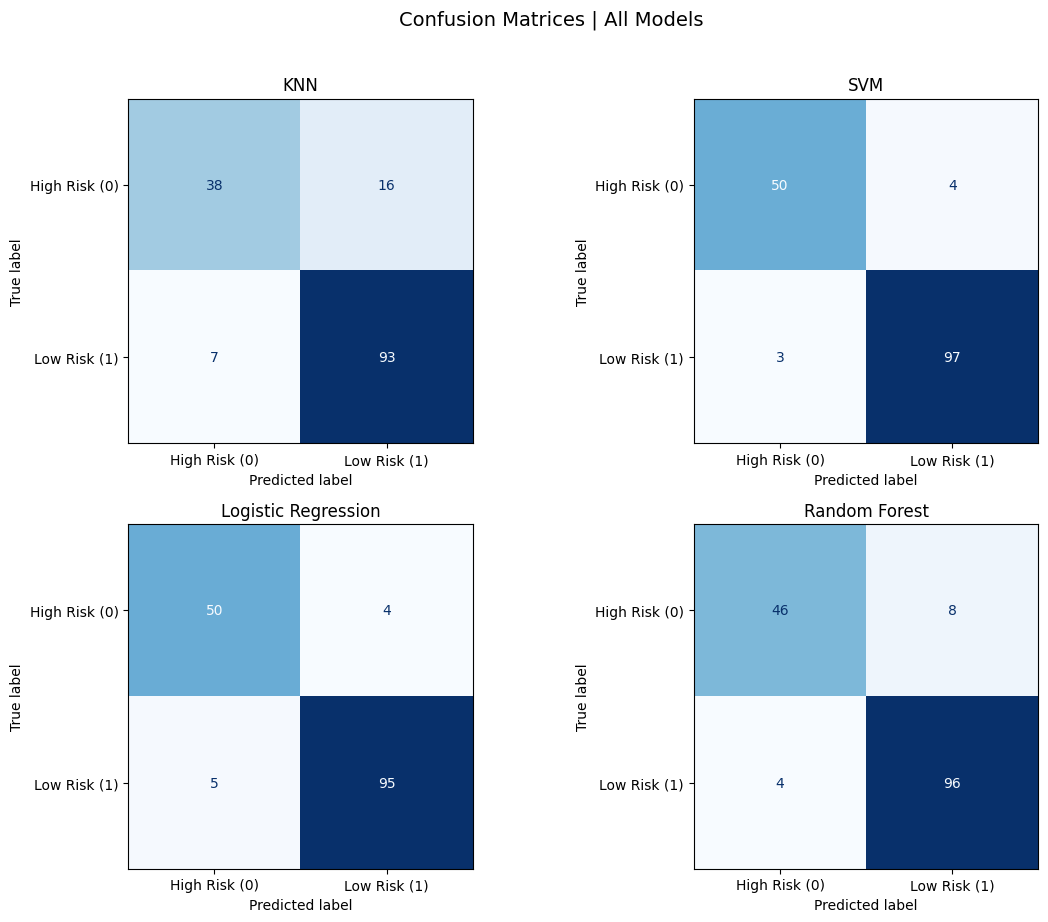

In [26]:
import pathlib
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()
for i, (name, gs) in enumerate(fitted_models.items()):
    y_pred_i = gs.best_estimator_.predict(X_test)
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred_i,
        display_labels=['High Risk (0)', 'Low Risk (1)'],
        colorbar=False, ax=axes[i], cmap='Blues',
    )
    axes[i].set_title(name, fontsize=12)
plt.suptitle('Confusion Matrices | All Models', fontsize=14, y=1.02)
plt.tight_layout()
fig_dir = pathlib.Path('..') / 'reports' / 'figures'
fig_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_dir / 'confusion_matrices.png', dpi=150, bbox_inches='tight')
print('Figure saved.'); plt.show()


## [9]  Pick the Best Model

We pick the model with the highest **weighted F1-Score**.  
F1 balances precision and recall & critical when missing a High Risk patient is costly.


In [27]:
best_name, best_pipeline = get_best_model(results_df, fitted_models)
print('\nBest hyperparameters:')
for k, v in fitted_models[best_name].best_params_.items(): print(f'  {k}: {v}')



>>> Best model: SVM (F1=0.9544)

Best hyperparameters:
  classifier__C: 10
  classifier__gamma: scale
  classifier__kernel: rbf


## [10] Full Evaluation of the Best Model

In [28]:
best_metrics = evaluate_model(best_pipeline, X_test, y_test, best_name)



  Results for: SVM
  Accuracy : 0.9545
  F1-Score : 0.9544

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.93        54
           1       0.96      0.97      0.97       100

    accuracy                           0.95       154
   macro avg       0.95      0.95      0.95       154
weighted avg       0.95      0.95      0.95       154

Confusion Matrix:
[[50  4]
 [ 3 97]]


## [11] Feature Importance (Random Forest)


In [29]:
from sklearn.ensemble import RandomForestClassifier
clf = best_pipeline.named_steps['classifier']
if isinstance(clf, RandomForestClassifier):
    importance = pd.Series(clf.feature_importances_, index=CLINICAL_FEATURES).sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(8, 4))
    importance.plot(kind='bar', ax=ax, color='#9b59b6', edgecolor='black')
    ax.set_title('Feature Importances | Random Forest')
    ax.set_ylabel('Importance'); plt.xticks(rotation=30, ha='right')
    plt.tight_layout(); plt.show()
    print(importance)
else:
    print(f'Best model is {best_name} | feature importance not available for this type.')


Best model is SVM | feature importance not available for this type.


## [12] Save the Final Pipeline

The `.joblib` file contains **StandardScaler + best classifier** as one object.  


In [30]:
saved_path = save_pipeline(best_pipeline)
print(f'Saved: {saved_path}')


Pipeline saved → C:\Users\hamza\Desktop\dev_ai\DiaSense\models\classification_pipeline.joblib
Saved: C:\Users\hamza\Desktop\dev_ai\DiaSense\models\classification_pipeline.joblib


## [13] Verify the Saved Pipeline

In [31]:
loaded_pipeline = load_pipeline()
y_reloaded = loaded_pipeline.predict(X_test)
assert np.array_equal(y_reloaded, best_metrics['y_pred']), 'Mismatch after reload!'
step_names = [name for name, _ in loaded_pipeline.steps]
print('Pipeline verified successfully.')
print(f'Steps: {step_names}')


Pipeline verified successfully.
Steps: ['scaler', 'classifier']
